# Practica 2 - Ejercicio 1: Calificaciones finales y horas de estudio

**Enunciado:** El dataset `student_data.csv` contiene el promedio de horas semanales de estudio
y la calificacion final de un conjunto de estudiantes. Se pide visualizar la relacion, calcular
la correlacion, ajustar un modelo de regresion lineal e interpretar los resultados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
%matplotlib inline

In [2]:
df = pd.read_csv("../Datasets/Parte_2/student_data.csv")
print(f"Dimensiones: {df.shape}")
print(df.head())
print(df.describe())

Dimensiones: (245, 3)
   Unnamed: 0  hours_studied  exam_scores
0           1            9.3         63.1
1           2           23.9         90.4
2           3           12.9         63.2
3           4           26.6         87.8
4           5           28.3         92.9
       Unnamed: 0  hours_studied  exam_scores
count  245.000000     245.000000   245.000000
mean   123.000000      15.573061    73.224082
std     70.869599       7.892464    11.805404
min      1.000000       1.000000    49.200000
25%     62.000000       8.700000    64.000000
50%    123.000000      15.000000    72.600000
75%    184.000000      21.600000    82.000000
max    245.000000      29.800000    96.900000


## 1. Visualizacion y correlacion

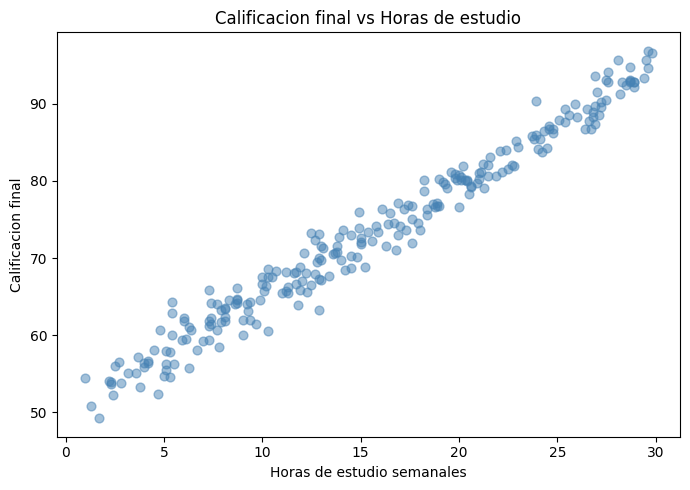

Correlacion de Pearson: r = 0.9861
p-valor: 2.1070e-191


In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["hours_studied"], df["exam_scores"], color="steelblue", alpha=0.5, s=40)
ax.set_xlabel("Horas de estudio semanales")
ax.set_ylabel("Calificacion final")
ax.set_title("Calificacion final vs Horas de estudio")
plt.tight_layout()
plt.show()

r, p_val = stats.pearsonr(df["hours_studied"], df["exam_scores"])
print(f"Correlacion de Pearson: r = {r:.4f}")
print(f"p-valor: {p_val:.4e}")

**Interpretacion:** La relacion entre las horas de estudio y la calificacion final es
**positiva y muy fuerte** (r ≈ 0.986). A mayor cantidad de horas de estudio, mayor es la
calificacion final. La correlacion de Pearson es la metrica adecuada para cuantificar
el grado de asociacion lineal entre dos variables cuantitativas.

## 2. Ajuste del modelo de regresion lineal

In [4]:
mod = smf.ols("exam_scores ~ hours_studied", data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:            exam_scores   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     8555.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          2.11e-191
Time:                        18:18:22   Log-Likelihood:                -512.26
No. Observations:                 245   AIC:                             1029.
Df Residuals:                     243   BIC:                             1036.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        50.2541      0.278    180.576

Modelo ajustado: exam_scores = 50.2541 + 1.4750 * hours_studied
R2 = 0.9724


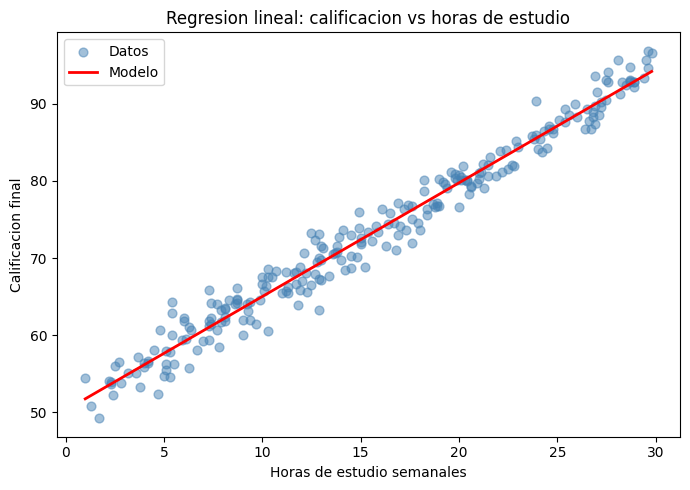

In [5]:
b0 = res.params["Intercept"]
b1 = res.params["hours_studied"]
print(f"Modelo ajustado: exam_scores = {b0:.4f} + {b1:.4f} * hours_studied")
print(f"R2 = {res.rsquared:.4f}")

# Grafico con recta ajustada
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["hours_studied"], df["exam_scores"], color="steelblue", alpha=0.5, s=40, label="Datos")
h_seq = np.linspace(df["hours_studied"].min(), df["hours_studied"].max(), 200)
ax.plot(h_seq, res.predict(pd.DataFrame({"hours_studied": h_seq})), color="red", lw=2, label="Modelo")
ax.set_xlabel("Horas de estudio semanales")
ax.set_ylabel("Calificacion final")
ax.set_title("Regresion lineal: calificacion vs horas de estudio")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Interpretacion del modelo

El modelo ajustado es:

$$\hat{calificacion} = 50.25 + 1.475 \cdot \text{horas\_estudio}$$

- **Intercepto (β₀ = 50.25):** Un estudiante que no dedica ninguna hora de estudio obtendria,
  en promedio, una calificacion de 50.25 puntos. Representa la calificacion base.
- **Pendiente (β₁ = 1.475):** Por cada hora semanal adicional de estudio, la calificacion final
  aumenta en promedio 1.475 puntos.
- **R² = 0.9724:** El modelo explica el 97.24% de la variabilidad en las calificaciones,
  indicando un ajuste excelente.
- Ambos coeficientes son estadisticamente significativos (p < 0.001).